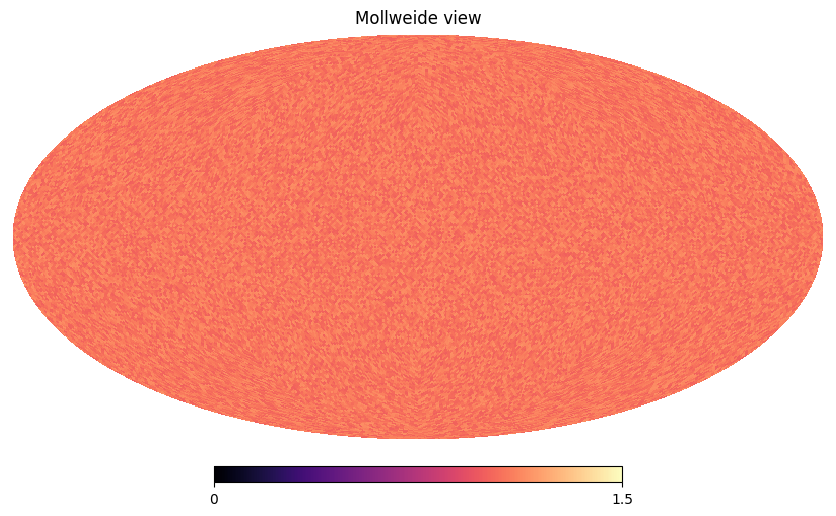

In [4]:
import healpy as hp
import numpy as np
import matplotlib.pyplot as plt

N = 2**6  # HEALPix map sides
n = hp.nside2npix(N)  # number of pixels
y = 1 + np.random.rand(n) * 0.15  # the map

hp.mollview(y, min=0, max=1.5, cmap="magma")

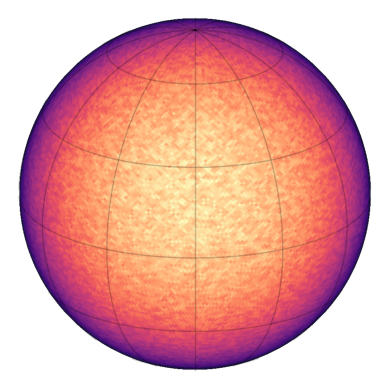

In [5]:
from spotter import Star, show

base_star = Star(y, u=(0.5, 0.2), inc=1.2, period=4.53)
show(base_star)

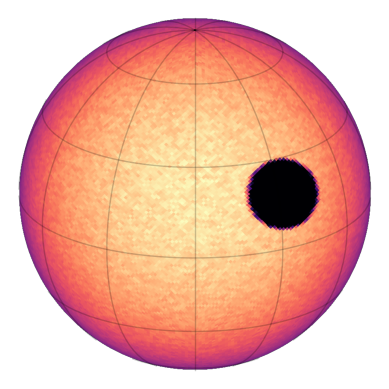

In [6]:
from spotter.star import transited_star

show(transited_star(base_star, y=0.5, r=0.2))

In [7]:
transited_star?

Signature:
transited_star(
    star: spotter.star.Star,
    x: float = 0.0,
    y: float = 0.0,
    z: float = 0.0,
    r: float = 0.0,
    time: float = None,
)
Docstring:
Return a star transited by a circular opaque disk

Parameters
----------
star : Star
    Star object to be transited.
x : float, optional
    x coordinate of the center of the disk, by default 0.0.
y : float, optional
    y coordinate of the center of the disk, by default 0.0.
r : float, optional
    Radius of the disk, by default 0.0.

Returns
-------
Star
    Star object transited by the disk.
File:      /opt/anaconda3/envs/fleckopy/lib/python3.12/site-packages/spotter/star.py
Type:      function

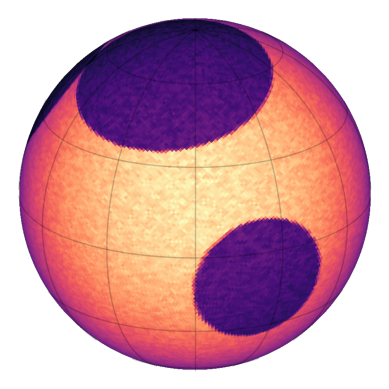

In [8]:
from spotter.core import spot

contrast = 0.7

chord_spot = spot(y, -0.2, 0.4, 0.4) 
pole_spot = spot(y, 1.2, -0.4, 0.6)
other_spot = spot(y, 0.6, -1.9, 0.4)
spots = np.array([chord_spot, pole_spot, other_spot])
star = base_star
for spot in spots:
    star -= spot * contrast
show(star)
plt.savefig('spotter_star.png')

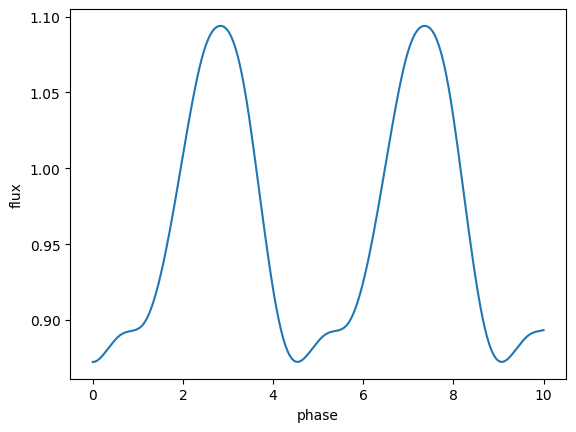

In [9]:
import jax
from spotter.light_curves import light_curve

time = np.linspace(0,10, 200)

plt.plot(time, light_curve(star, time)[0])
plt.xlabel("phase")
_ = plt.ylabel("flux")

In [10]:
from spotter import distributions
from spotter.core import amplitude

# generate maps with a single random spot
n_spots = 500
latlon = distributions.uniform(n_spots)
radii = np.random.uniform(0.01, 0.9, n_spots)
contrast = np.random.uniform(0.01, 0.9, n_spots)
ys = 1 - jax.vmap(jax.jit(spot, static_argnums=(0,)), in_axes=(None, 0, 0, 0))(
    N, *latlon, radii
)

amplitude = jax.jit(amplitude(N, u=star.u[0]))
values = amplitude(ys)

TypeError: Expected a callable value, got [0. 0. 0. ... 0. 0. 0.]

In [ ]:
%timeit amplitude(ys)

In [11]:
# trivial
spotted = star.y < 1.0
coverage = np.mean(spotted)

print(f"coverage: {coverage * 100:.2f}%")

coverage: 16.76%


chord coverage: 2.29%


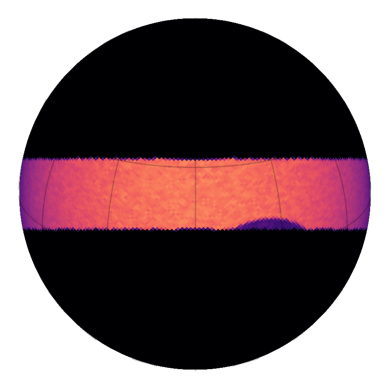

In [12]:
from spotter.core import mask_projected_limb, transit_chord, vec

transit = transit_chord(N, 0.0, 0.2, star.inc)

mask, area, _ = mask_projected_limb(vec(N), u=star.u[0], inc=star.inc)

spotted = (star.y[0] < 1.0) * mask
transited = transit * mask > 0.0

# let's show the chord
show(star * transited, vmin=0.0, vmax=1.5)

# covering fraction in the chord
chord_coverage = (spotted * transited * area).sum() / (transited * area).sum()
print(f"chord coverage: {chord_coverage * 100:.2f}%")

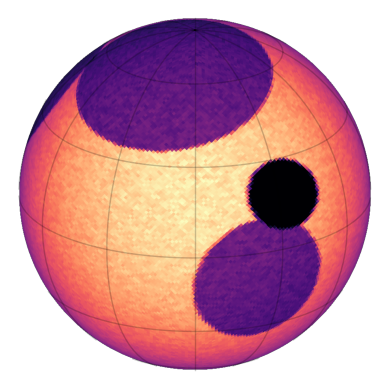

In [13]:
from spotter.star import transited_star

show(transited_star(star, y=0.5, r=0.2))

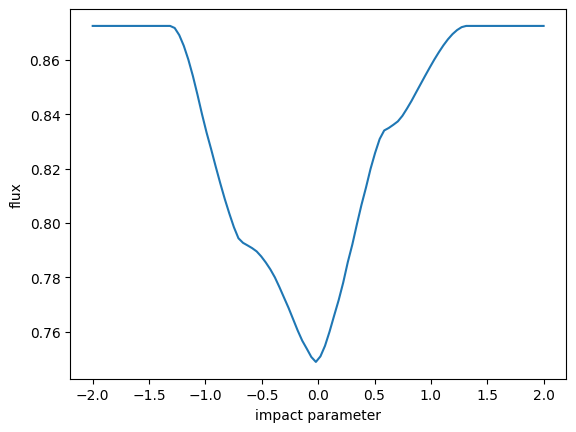

In [14]:
from spotter.light_curves import transit_light_curve

# impact parameter
b = np.linspace(-2, 2, 100)

flux = jax.vmap(lambda b: transit_light_curve(star, y=b, r=0.3)[0])(b)
plt.plot(b, flux)
plt.xlabel("impact parameter")
_ = plt.ylabel("flux")

In [15]:
from spotter.core import vec

N = 2**5  # number of sides
u = (0.4, 0.2)  # limb darkening coefficient
X = vec(N)  # pixels coordinates

In [ ]:
import tinygp
from spotter.kernels import GreatCircleDistance

kernel = 0.1 * tinygp.kernels.Matern52(0.6, distance=GreatCircleDistance())
gp = tinygp.GaussianProcess(kernel, X)

In [ ]:
viz.show?

In [ ]:
import jax
import matplotlib.pyplot as plt
from spotter import viz

y = gp.sample(jax.random.PRNGKey(5), shape=(1,))[0]
y = 1.0 - y.clip(0.0, 1.0)

plt.style.use('dark_background')  # This sets black background with white elements
plt.figure(figsize=(4, 4))
viz.show(y, u=u,phase=0.3)
plt.savefig('spotter-star.png',dpi=300)

In [ ]:
from matplotlib.animation import PillowWriter
import matplotlib.pyplot as plt

# Set up the figure with black background
plt.figure(figsize=(4, 4), facecolor='black')
ax = plt.gca()
ax.set_facecolor('black')

# Configure visible elements
ax.tick_params(colors='black')
for spine in ax.spines.values():
    spine.set_color('black')

# Create animation writer
writer = PillowWriter(fps=60)  # Adjust fps for speed

# Generate 100 frames with phase from 0 to 1
phases = np.linspace(0, 1, 600)

with writer.saving(plt.gcf(), 'spotter-star.gif', dpi=200):
    for phase in phases:
        ax.clear()
        
        # Reapply black background and styling after clear
        ax.set_facecolor('black')
        ax.tick_params(colors='black')
        for spine in ax.spines.values():
            spine.set_color('black')
        
        # Create the plot for this phase
        viz.show(y, u=u, phase=phase)
        
        # Update any labels if needed
        # ax.set_title(f"Phase: {phase:.2f}", color='white')
        
        writer.grab_frame()

print("GIF created successfully!")

In [ ]:
from matplotlib import gridspec

length_scales = [0.1, 0.2, 0.3, 0.4, 0.5]
gridspec.GridSpec(1, 6)
plt.figure(figsize=(12, 2))

for i, l in enumerate(length_scales):
    kernel = 0.1 * tinygp.kernels.Matern52(l, distance=GreatCircleDistance())
    gp = tinygp.GaussianProcess(kernel, X)
    y = gp.sample(jax.random.PRNGKey(i + 1), shape=(1,))[0]
    y = 1.0 - y.clip(0.0, 1.0)
    plt.subplot(1, 6, i + 1)
    viz.show(y, u=u)
    plt.title(f"l={l}")

In [1]:
from spotter import kernels

kernel = kernels.ActiveLatitude(
    kernel=0.1 * tinygp.kernels.Matern52(0.3, distance=kernels.GreatCircleDistance()),
    latitude=0.5,
    sigma=0.2,
    symetric=True,
)

gp = tinygp.GaussianProcess(kernel, X)

NameError: name 'tinygp' is not defined

In [2]:
import jax.numpy as jnp

cos_theta = X.T[2] / jnp.linalg.norm(X.T, axis=0)
_ = plt.plot(cos_theta, jax.vmap(kernel.amplitude)(vec(N)))

NameError: name 'X' is not defined

In [3]:
import jax
import matplotlib.pyplot as plt
from spotter import viz

y = gp.sample(jax.random.PRNGKey(6), shape=(1,))[0]
y = 1.0 - y.clip(0.0, 1.0)

plt.figure(figsize=(2, 2))
viz.show(y, u=u)

NameError: name 'gp' is not defined

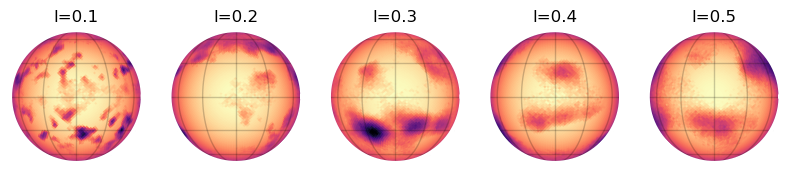

In [24]:
from matplotlib import gridspec

lenght_scales = [0.1, 0.2, 0.3, 0.4, 0.5]
gridspec.GridSpec(1, 6)
plt.figure(figsize=(12, 2))

for i, l in enumerate(lenght_scales):
    kernel = kernels.ActiveLatitude(
        kernel=0.1 * tinygp.kernels.Matern52(l, distance=kernels.GreatCircleDistance()),
        latitude=0.5,
        sigma=0.2,
        symetric=True,
    )
    gp = tinygp.GaussianProcess(kernel, X)
    y = gp.sample(jax.random.PRNGKey(i), shape=(1,))[0]
    y = 1.0 - y.clip(0.0, 1.0)
    plt.subplot(1, 6, i + 1)
    viz.show(y, u=u)
    plt.title(f"l={l}")

In [25]:
tinygp.kernels.Matern52?

Init signature:
tinygp.kernels.Matern52(
    scale: 'JAXArray | float' = <factory>,
    distance: 'Distance' = <factory>,
) -> None
Docstring:     
The Matern-5/2 kernel

.. math::

    k(\mathbf{x}_i,\,\mathbf{x}_j) = (1 + \sqrt{5}\,r +
        5\,r^2/3)\,\exp(-\sqrt{5}\,r)

where, by default,

.. math::

    r = ||(\mathbf{x}_i - \mathbf{x}_j) / \ell||_1

Args:
    scale: The parameter :math:`\ell`.
File:           /opt/anaconda3/envs/fleckopy/lib/python3.10/site-packages/tinygp/kernels/stationary.py
Type:           _ActualModuleMeta
Subclasses:     Matern52

In [26]:
kernel = kernels.ActiveLatitude(
    kernel=1.0 * tinygp.kernels.Matern52(0.7, distance=kernels.GreatCircleDistance()),
    latitude=jnp.pi / 2,
    sigma=1,
    symetric=True,
)
gp = tinygp.GaussianProcess(kernel, X)

y = gp.sample(jax.random.PRNGKey(1), shape=(1,))[0]
y = 1.0 - y.clip(0.0, 1.0)

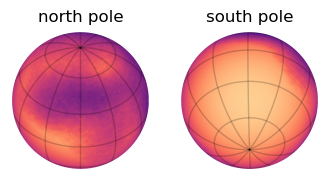

In [27]:
plt.figure(figsize=(4, 2))
ax = plt.subplot(121)
viz.show(y, inc=0.85, u=u, ax=ax, vmin=0.1, vmax=1.1,phase=0.0)
ax.set_title("north pole")

ax = plt.subplot(122)
viz.show(y, inc=jnp.pi / 2 + 0.85, u=u, ax=ax, vmin=0.1, vmax=1.1,phase=0.0)
_ = ax.set_title("south pole")